In [60]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Root directory for all results
BASE_DIR = Path("./results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000")


In [61]:
main_result_path = {
    "vanilla":
    [
        "20260115-012027_MLP_FSNet_seed0_nepochs300_lr0.0001_trainsize7000",
        # "20260115-013345_MLP_FSNet_seed1_nepochs300_lr0.0001_trainsize7000",
        "20260115-012025_MLP_FSNet_seed2_nepochs300_lr0.0001_trainsize7000",
        "20260115-013254_MLP_FSNet_seed3_nepochs300_lr0.0001_trainsize7000",
    ],
    "pretraining":
    [
        "20260115-184556_MLP_sup_pen_seed0_nepochs1000_lr0.0001_trainsize7000_subopt_3_3.0",
    ],
    'ours':
    [
        "20260117-185928_MLP_FSNet_seed0_nepochs300_lr0.0001_trainsize7000_finetune_20260115-184556_sup_seedpen_model_150",
        # "20260117-185930_MLP_FSNet_seed2_nepochs300_lr0.0001_trainsize7000_finetune_20260115-184556_sup_seedpen_model_150",
        "20260117-191324_MLP_FSNet_seed1_nepochs300_lr0.0001_trainsize7000_finetune_20260115-184556_sup_seedpen_model_150",
        "20260117-191337_MLP_FSNet_seed3_nepochs300_lr0.0001_trainsize7000_finetune_20260115-184556_sup_seedpen_model_150",
    ], # 3.0
}

In [62]:
# --- Functions ---
def load_results(path):
    with open(path, 'rb') as f:
        return pickle.load(f)

def get_metrics(results, history_key='val_history'):
    if history_key not in results or not results[history_key]:
        return None
    metrics = {k: [] for k in results[history_key][0].keys()}
    for entry in results[history_key]:
        for key in metrics.keys():
            metrics[key].append(entry[key])
    return {k: np.array(v) for k, v in metrics.items()}

def load_and_recompute(result_paths, base_path):
    data_tree = {}
    for method, folders in result_paths.items():
        data_tree[method] = []
        for folder in folders:
            p = base_path / folder / "results.pkl"
            if p.exists():
                res = load_results(p)
                m = get_metrics(res, 'val_history')
                eq_weight = 1e5
                ineq_weight = 1e5   
                
                # Recompute Merit Mean using requested keys
                m['recomputed_merit_mean'] = (
                    m['objective'] + 
                    eq_weight * m['eq_violation_l1_mean'] + ineq_weight * m['ineq_violation_l1_mean']
                )
                
                m['recomputed_merit_max'] = (
                    m['objective_max'] + 
                    eq_weight * m['eq_violation_l1_max'] + ineq_weight * m['ineq_violation_l1_max']
                )
                
                data_tree[method].append(m)
            else:
                print(f"Warning: Path not found {p}")
    return data_tree

In [63]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

SKIP = 1
LINE_WIDTH = 4
BASE_SIZE = 24

# Use two palettes:
# - FILL_COLORS: light (for bands)
# - LINE_COLORS: darker (for strokes, markers, annotation)
FILL_COLORS = {
    "vanilla": "#F2B8A2",      # light peach
    "pretraining": "#9BB7D4",  # light steel-blue
    "ours": "#BFE5D3",         # light teal-green
}
LINE_COLORS = {
    "vanilla": "#C97D77",     # muted brick red
    "pretraining": "#3E6E9E", # steel blue
    "ours": "#6E8F71",        # sage green (updated)
}
STYLES = {"vanilla": "--", "pretraining": "-", "ours": "-"}  # keep your original


def plot_learning_dual_axis(data_tree, metric_name="recomputed_merit_mean"):
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # -----------------------------
    # Left axis: SSL training curves
    # -----------------------------
    ax1.set_xlabel("# epochs", fontsize=BASE_SIZE)
    ax1.set_ylabel("SSL training", fontsize=BASE_SIZE)

    # Annotation: start SSL
    ax1.axvline(x=300, color=LINE_COLORS["vanilla"], linestyle="--", linewidth=3, alpha=0.7)

    # Defensive: pick a reasonable y for the text even if metric array shape differs
    try:
        y0 = float(data_tree["vanilla"][0][metric_name][0])
    except Exception:
        y0 = 50.0

    ax1.text(
        310,
        y0 * 1.5,
        "start SSL",
        fontsize=BASE_SIZE - 4,
        verticalalignment="top",
        color=LINE_COLORS["vanilla"],
        alpha=1.0,
        fontweight="bold",
    )

    methods_to_plot = {
        "vanilla": "vanilla",
        "ours": "ours",
    }

    for label, key in methods_to_plot.items():
        if key in data_tree and data_tree[key]:
            runs = data_tree[key]

            # SHIFT LOGIC: Add 300 to the epoch array
            epochs = np.array(runs[0]["epoch"][0:]) + 300

            # Average over runs
            vals = np.mean([np.array(run[metric_name][0:]) for run in runs], axis=0)

            ax1.plot(
                epochs,
                vals,
                label=label,
                color=LINE_COLORS[key],
                linestyle=STYLES[key],
                linewidth=LINE_WIDTH * 1.1,
            )

            # Uncertainty band
            if len(runs) > 1:
                std = np.std([np.array(run[metric_name][0:]) for run in runs], axis=0)
                ax1.fill_between(
                    epochs,
                    vals - std,
                    vals + std,
                    color=FILL_COLORS[key],
                    alpha=0.35,
                    linewidth=0,
                )

    # Spines
    for spine in ax1.spines.values():
        spine.set_linewidth(LINE_WIDTH - 1)
        spine.set_color("black")

    # Axis limits/ticks
    ax1.set_ylim(-10, 80)
    ax1.set_xlim(0, 700)
    ax1.set_xticks([0, 200, 300, 400, 600])
    ax1.locator_params(axis="y", nbins=4)
    ax1.locator_params(axis="x", nbins=6)
    ax1.set_facecolor("white")
    ax1.tick_params(axis="y", labelsize=BASE_SIZE - 4, width=LINE_WIDTH, length=8, color="black")
    ax1.tick_params(axis="x", labelsize=BASE_SIZE - 4, width=LINE_WIDTH, length=8, color="black")
    ax1.set_title("average merit", fontsize=BASE_SIZE + 2, pad=15)

    # -----------------------------
    # Right axis: SL pretraining curve
    # -----------------------------
    ax2 = None
    if "pretraining" in data_tree and data_tree["pretraining"]:
        ax2 = ax1.twinx()
        ax2.set_ylabel("SL pretraining", fontsize=BASE_SIZE, color=LINE_COLORS["pretraining"])

        runs = data_tree["pretraining"]
        epochs = np.array(runs[0]["epoch"][SKIP:])
        vals = np.mean([np.array(run[metric_name][SKIP:]) for run in runs], axis=0)

        # Use dark line + markers; if you ever switch to 'o', use hollow markers
        ax2.plot(
            epochs,
            vals,
            label="pretraining",
            color=LINE_COLORS["pretraining"],
            linewidth=LINE_WIDTH * 1.1,
            marker="x",
            markersize=15,
            markevery=5,
        )

        if len(runs) > 1:
            std = np.std([np.array(run[metric_name][SKIP:]) for run in runs], axis=0)
            ax2.fill_between(
                epochs,
                vals - std,
                vals + std,
                color=FILL_COLORS["pretraining"],
                alpha=0.35,
                linewidth=0,
            )

        ax2.tick_params(
            axis="y",
            labelsize=BASE_SIZE - 4,
            width=LINE_WIDTH,
            length=8,
            color="black",
            labelcolor=LINE_COLORS["pretraining"],
        )
        ax2.spines["top"].set_visible(False)

        # Right-axis limits: keep the curve near the bottom if that's what you intended
        data_min = float(np.min(vals))
        data_max = float(np.max(vals))
        ax2.set_ylim(data_min * 0.0, data_max * 0.1)
        ax2.locator_params(axis="y", nbins=4)

        # Force scientific notation: 10^5
        formatter = ScalarFormatter(useMathText=True)
        formatter.set_scientific(True)
        formatter.set_powerlimits((5, 5))
        ax2.yaxis.set_major_formatter(formatter)
        ax2.yaxis.get_offset_text().set_fontsize(BASE_SIZE - 6)
        ax2.yaxis.get_offset_text().set_position((1.02, 1))

    # -----------------------------
    # Legend (merge if twin axis exists)
    # -----------------------------
    if ax2 is not None:
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(
            lines1 + lines2,
            labels1 + labels2,
            frameon=True,
            loc="lower left",
            fontsize=BASE_SIZE - 6,
        )
    else:
        ax1.legend(frameon=True, loc="lower left", fontsize=BASE_SIZE - 6)

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    # Example usage:
    # plot_learning_dual_axis(data_tree, metric_name="recomputed_merit_mean")
    pass


In [64]:
processed_data = load_and_recompute(main_result_path, BASE_DIR)

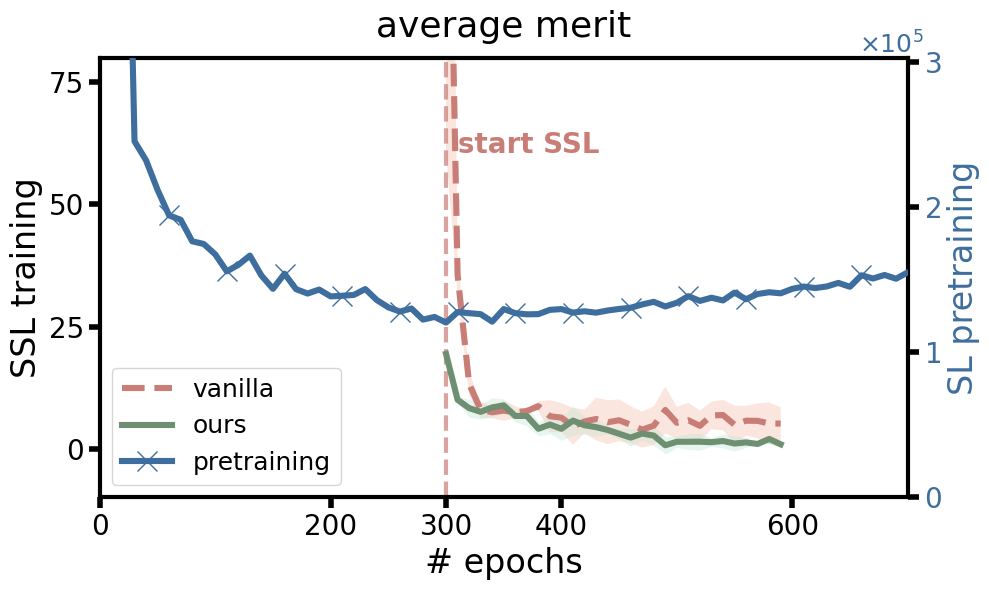

In [65]:
plot_learning_dual_axis(processed_data)